# Thesis - XAI
by Azhar Rafiq

Dataset in BlueBEAR:
- ✅[ downloaded] RSNA (kaggle.com/competitions/rsna-intracranial-hemorrhage-detection)
- [later] PhysioNet (physionet.org/content/ct-ich/1.3.1/)

In [1]:
#library
import os
from dotenv import load_dotenv

load_dotenv()

import sys
# check venv
print(sys.executable)

import glob

import numpy as np
import pandas as pd

import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt

import random

import tensorflow as tf
from tensorflow.keras import models, layers, losses, optimizers
from tensorflow.keras import callbacks

import sklearn
from sklearn.model_selection import GridSearchCV, StratifiedKFold

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import make_scorer, roc_auc_score, roc_curve, recall_score

import scikeras
from scikeras.wrappers import KerasClassifier
from skimage.transform import resize

import joblib

#

import pydicom
from pathlib import Path
import collections
import datetime

from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

import nibabel as nib

##

print("✅ Libraries imported succesfully\n")

print(f"🐍 Python Version: {sys.version.split()[0]}")
print(f"📖 Pandas Version: {pd.__version__}")
print(f"📖 Numpy Version: {np.__version__}")
print(f"📖 Seaborn Version: {sns.__version__}")

# print(f"📖 Tensorflow Version: {tf.__version__}")
print(f"📖 Joblib Version: {joblib.__version__}")

print(f"📖 PyDICOM Version: {pydicom.__version__}")
print(f"📖 nibabel Version: {nib.__version__}")

print(f"📖 Scikit-Learn Version: {sklearn.__version__}")
print(f"📖 scikeras Version: {scikeras.__version__}")


/rds/homes/a/axr1222/thesis-xai/thesis-venv/bin/python3.12


I0000 00:00:1779201355.785124 3631767 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779201358.241291 3631767 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779201369.465183 3631767 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


✅ Libraries imported succesfully

🐍 Python Version: 3.12.3
📖 Pandas Version: 3.0.2
📖 Numpy Version: 2.4.4
📖 Seaborn Version: 0.13.2
📖 Joblib Version: 1.5.3
📖 PyDICOM Version: 3.0.2
📖 nibabel Version: 5.4.2
📖 Scikit-Learn Version: 1.8.0
📖 scikeras Version: 0.13.0


## Import Dataset

### Import RSNA Dataset

In [2]:
# #import RSNA dataset

# import kagglehub
# kagglehub.login()


In [3]:
#specify dataset directory
os.environ['KAGGLEHUB_CACHE'] = os.getenv('KAGGLE_CACHE')
# os.makedirs(os.environ['KAGGLEHUB_CACHE'], exist_ok=True)

# rsnapath = kagglehub.competition_download('rsna-intracranial-hemorrhage-detection')
# rsnapath
# #files already downloaded

In [4]:
#load files
#files already separated by the RSNA Kaggle Challenge

BASE = Path('.')
RSNA_TRAIN_DIR = BASE / os.environ['KAGGLEHUB_CACHE'] / 'competitions/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection/stage_2_train'
RSNA_TEST_DIR = BASE / os.environ['KAGGLEHUB_CACHE'] / 'competitions/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection/stage_2_test'

labels_rsna_df = pd.read_csv(BASE / os.environ['KAGGLEHUB_CACHE'] / 'competitions/stage_2_train.csv')

#count RSNA training files
print(f'RSNA Train DICOMs: {len(list(RSNA_TRAIN_DIR.glob("*.dcm")))}')
print(f'RSNA Test DICOMs: {len(list(RSNA_TEST_DIR.glob("*.dcm")))}')

RSNA Train DICOMs: 752803
RSNA Test DICOMs: 121142


In [5]:
# no cuda/gpu used right now
# check cuda
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Import Physionet Dataset

Import data from Physionet.

In [6]:
os.environ['PHYSIO_CACHE'] = os.getenv('PHYSIO_CACHE')
# os.makedirs(os.environ['PHYSIO_CACHE'], exist_ok=True)

In [7]:
# !wget -r -N -c -np --user azharrafiq --ask-password -P os.environ['PHYSIO_CACHE'] https://physionet.org/files/ct-ich/1.3.1/

In [8]:
PHYSIONET_DIR = BASE / os.environ['PHYSIO_CACHE'] / 'physionet.org/files/ct-ich/1.3.1'

print(f'PhysioNet scans: {len(list((PHYSIONET_DIR / "ct_scans").glob("*.nii")))}')
print(f'PhysioNet masks: {len(list((PHYSIONET_DIR / "masks").glob("*.nii")))}')

PhysioNet scans: 75
PhysioNet masks: 75


## Exploratory Data Analysis

### RSNA EDA

In [9]:
#check metadata

dcm_files = list(RSNA_TRAIN_DIR.glob('*.dcm'))
ds = pydicom.dcmread(str(dcm_files[0]))
ds

/rds/homes/a/axr1222/thesis-xai/thesis-venv/lib/python3.12/site-packages/pydicom/valuerep.py:440: UserWarning: The value length (20) exceeds the maximum length of 16 allowed for VR SH.
  warn_and_log(msg)
/rds/homes/a/axr1222/thesis-xai/thesis-venv/lib/python3.12/site-packages/pydicom/valuerep.py:440: UserWarning: Invalid value for VR UI: 'ID_69e273863'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)
/rds/homes/a/axr1222/thesis-xai/thesis-venv/lib/python3.12/site-packages/pydicom/valuerep.py:440: UserWarning: Invalid value for VR UI: 'ID_5c33a2b716'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)
/rds/homes/a/axr1222/thesis-xai/thesis-venv/lib/python3.12/site-packages/pydicom/valuerep.py:440: UserWarning: Invalid value for VR UI: 'ID_9bb83869e0'. Please see <https://dicom.nema.org/medical/di

Dataset.file_meta -------------------------------
(0002,0002) Media Storage SOP Class UID         UI: CT Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 10000000024592
(0002,0010) Transfer Syntax UID                 UI: Implicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.2.3.4
(0002,0013) Implementation Version Name         SH: 'RSNA Challenge 2019'
-------------------------------------------------
(0008,0018) SOP Instance UID                    UI: ID_69e273863
(0008,0060) Modality                            CS: 'CT'
(0010,0020) Patient ID                          LO: 'ID_048703f5'
(0020,000D) Study Instance UID                  UI: ID_5c33a2b716
(0020,000E) Series Instance UID                 UI: ID_9bb83869e0
(0020,0010) Study ID                            SH: ''
(0020,0032) Image Position (Patient)            DS: [-125, -13, 205.099976]
(0020,0037) Image Orientation (Patient)         DS: [1, 0, 0, 0, 1, 0]
(0028,0002) Samples per Pixel 

In [ ]:
#check dicom tag keywords
# [x for x in dir(ds) if not x.startswith('_')]

This dataset possibly has 4 different kind of ID/UID:
- SOP Instance UID, patient ID, study instance UID, and series intance UID


example:

- (0008,0018) SOP Instance UID                    UI: ID_69e273863
- (0008,0060) Modality                            CS: 'CT'
- (0010,0020) Patient ID                          LO: 'ID_048703f5'
- (0020,000D) Study Instance UID                  UI: ID_5c33a2b716
- (0020,000E) Series Instance UID                 UI: ID_9bb83869e0

I will analyse all the DICOM metadata.

In [11]:
#log all metadata in csv
#move to slurm

Checking raw image data:

In [12]:
ds.pixel_array

array([[11, 11, 12, ..., 12, 11, 10],
       [12, 12, 12, ..., 12, 11, 11],
       [12, 13, 13, ..., 12, 12, 13],
       ...,
       [15, 15, 14, ..., 15, 15, 15],
       [15, 15, 14, ..., 14, 14, 15],
       [14, 15, 15, ..., 14, 14, 15]], shape=(512, 512), dtype=uint16)

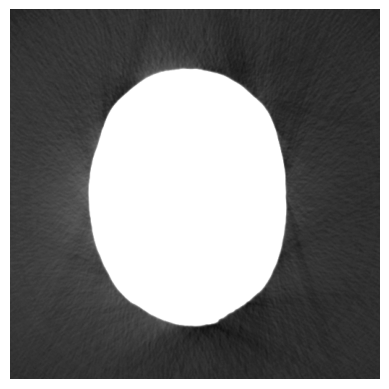

In [13]:
#show image using raw pixel_array
ds = pydicom.dcmread(str(dcm_files[0]))
pixel_array = ds.pixel_array.astype(np.float32)
plt.imshow(pixel_array, cmap='gray', vmin=0, vmax=80)
plt.axis('off')
plt.show()

The original DICOM will shows image too bright, 
so I need to convert to Hounsfield Units (HU) 
using rescale intercept and slope.


example from image index[0]:
(0028,1052) Rescale Intercept                   DS: '-1024'
(0028,1053) Rescale Slope                       DS: '1'

In [14]:
ds.RescaleIntercept

'-1024'

/rds/homes/a/axr1222/thesis-xai/thesis-venv/lib/python3.12/site-packages/pydicom/valuerep.py:440: UserWarning: Invalid value for VR UI: 'ID_d7a634ec77'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)


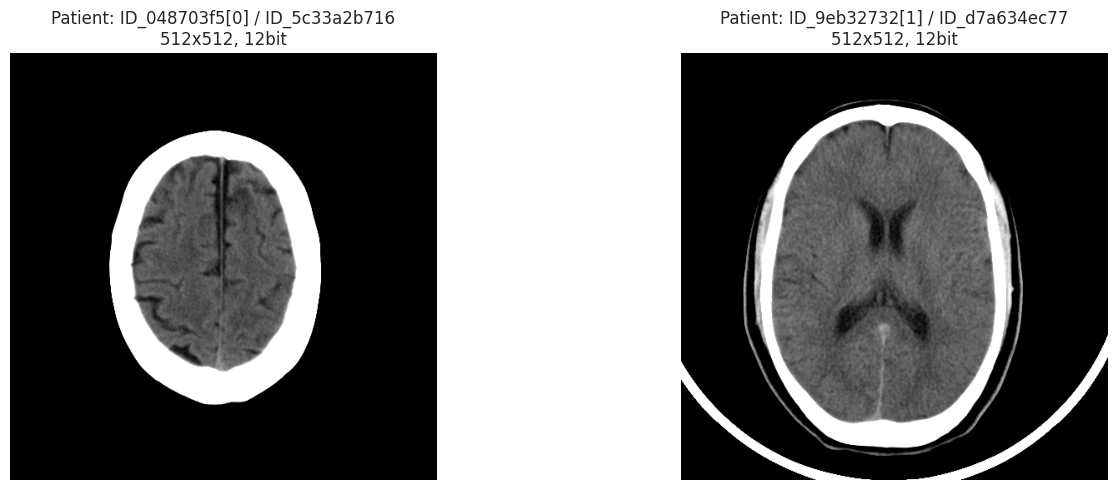

In [15]:
#show image with hounsfield unit
if dcm_files:
    n_images = 2
    n_cols = 2
    n_rows = (n_images + n_cols - 1) // n_cols  #ceiling division

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten()

    for i in range(n_images):
        ds = pydicom.dcmread(str(dcm_files[i]))
        pixel_array = ds.pixel_array.astype(np.float32)
        
        #converts to Hounsfield Units
        hu = pixel_array * ds.RescaleSlope + ds.RescaleIntercept

        axes[i].imshow(hu, cmap='gray', vmin=0, vmax=80)
        axes[i].set_title(f'Patient: {ds.PatientID}[{i}] / {ds.StudyInstanceUID}\n{ds.Rows}x{ds.Columns}, {ds.BitsStored}bit')
        axes[i].axis('off')

    #hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

It is logical to have different study patient ID each patient, but if:
1. MULTIPLE IMAGE of SAME patient ID + SAME study ID = one patient have multiple slices in same study
2. MULTIPLE IMAGE of SAME patient ID + DIFFERENT study ID = one patient have multiple study (repeat/different CT Scan)

Analysing metadata:

Check non unique IDs count to show how many images are not only 1 slice from 1 patient:

In [16]:
!ls

build_dicom_index.py	    dicom_index_42390824.stats
dicom_index_42368562.out    jobindexdicom.sh
dicom_index_42368562.stats  model_newww1.pkl
dicom_index_42368788.out    requirements.txt
dicom_index_42368788.stats  roc_baseline.png
dicom_index_42368954.out    rsna_model_1142_auc.h5
dicom_index_42368954.stats  slices_per_study_dist.png
dicom_index_42369339.out    thesis.ipynb
dicom_index_42369339.stats  thesis-venv
dicom_index_42390824.out


In [17]:
df = pd.read_csv('/rds/homes/a/axr1222/rsna_dicom_index_2.csv') #output of slurm job

print('PatientID ---')
print(df.groupby('split')['PatientID'].nunique())
print('StudyInstanceUID ---')
print(df.groupby('split')['StudyInstanceUID'].nunique())
print('SeriesInstanceUID ---')
print(df.groupby('split')['SeriesInstanceUID'].nunique())
print('SOPInstanceUID ---')
print(df.groupby('split')['SOPInstanceUID'].nunique())

PatientID ---
split
test      3518
train    18938
Name: PatientID, dtype: int64
StudyInstanceUID ---
split
test      3518
train    21744
Name: StudyInstanceUID, dtype: int64
SeriesInstanceUID ---
split
test      3518
train    21744
Name: SeriesInstanceUID, dtype: int64
SOPInstanceUID ---
split
test     121142
train    752803
Name: SOPInstanceUID, dtype: int64


In [18]:
#summarizing
summary = df.groupby('split').agg(
    Total_Files       = ('filename',         'count'),
    Unique_Patients   = ('PatientID',        'nunique'),
    Unique_Studies    = ('StudyInstanceUID',  'nunique'),
    Unique_Series     = ('SeriesInstanceUID', 'nunique'),
    Unique_Slices     = ('SOPInstanceUID',    'nunique'),
).T

summary['total'] = summary.sum(axis=1)

# Slices per group
summary.loc['Avg Slices per Patient'] = (summary.loc['Total_Files'] / summary.loc['Unique_Patients']).round(1)
summary.loc['Avg Slices per Study']   = (summary.loc['Total_Files'] / summary.loc['Unique_Studies']).round(1)
summary.loc['Avg Slices per Series']  = (summary.loc['Total_Files'] / summary.loc['Unique_Series']).round(1)

print(summary.to_string())

split                       test     train     total
Total_Files             121142.0  752803.0  873945.0
Unique_Patients           3518.0   18938.0   22456.0
Unique_Studies            3518.0   21744.0   25262.0
Unique_Series             3518.0   21744.0   25262.0
Unique_Slices           121142.0  752803.0  873945.0
Avg Slices per Patient      34.4      39.8      38.9
Avg Slices per Study        34.4      34.6      34.6
Avg Slices per Series       34.4      34.6      34.6


This is apparently volumetric dataset. Each patient has its own multiple CT Scan slices. I should check the sample for a patient:

In [19]:
df.describe()

,ImagePositionZ,InstanceNumber
count,873945.000000,0.0
mean,168.720927,NaN
std,247.918089,NaN
min,-998.400024,NaN
25%,67.500000,NaN
50%,123.968000,NaN
75%,186.754776,NaN
max,1794.012760,NaN


In [20]:
check_sample = df[df['PatientID']=="ID_048703f5"]
check_sample.count()

filename             40
split                40
PatientID            40
StudyInstanceUID     40
SeriesInstanceUID    40
SOPInstanceUID       40
ImagePositionZ       40
InstanceNumber        0
dtype: int64

In [21]:
check_sample

,filename,split,PatientID,StudyInstanceUID,SeriesInstanceUID,SOPInstanceUID,ImagePositionZ,InstanceNumber
0,ID_69e273863.dcm,train,ID_048703f5,ID_5c33a2b716,ID_9bb83869e0,ID_69e273863,205.099976,NaN
8638,ID_6a56f4d7d.dcm,train,ID_048703f5,ID_5c33a2b716,ID_9bb83869e0,ID_6a56f4d7d,125.099976,NaN
20797,ID_abe7db767.dcm,train,ID_048703f5,ID_5c33a2b716,ID_9bb83869e0,ID_abe7db767,200.099976,NaN
29122,ID_0082f9066.dcm,train,ID_048703f5,ID_5c33a2b716,ID_9bb83869e0,ID_0082f9066,130.099976,NaN
70326,ID_9960426fa.dcm,train,ID_048703f5,ID_5c33a2b716,ID_9bb83869e0,ID_9960426fa,195.099976,NaN
103197,ID_ee3626bdd.dcm,train,ID_048703f5,ID_5c33a2b716,ID_9bb83869e0,ID_ee3626bdd,190.099976,NaN
121123,ID_a003e82fd.dcm,train,ID_048703f5,ID_5c33a2b716,ID_9bb83869e0,ID_a003e82fd,215.099976,NaN
121583,ID_b8aa09f9f.dcm,train,ID_048703f5,ID_5c33a2b716,ID_9bb83869e0,ID_b8aa09f9f,155.099976,NaN
130747,ID_30ca14fbe.dcm,train,ID_048703f5,ID_5c33a2b716,ID_9bb83869e0,ID_30ca14fbe,240.099976,NaN
180769,ID_f79a78e9c.dcm,train,ID_048703f5,ID_5c33a2b716,ID_9bb83869e0,ID_f79a78e9c,170.099976,NaN


In [22]:
#rerun slurm to fetch other metadata to check image order of the study

#reorder image based on z image position of dicom

In [23]:
check_sample = check_sample.sort_values("ImagePositionZ")

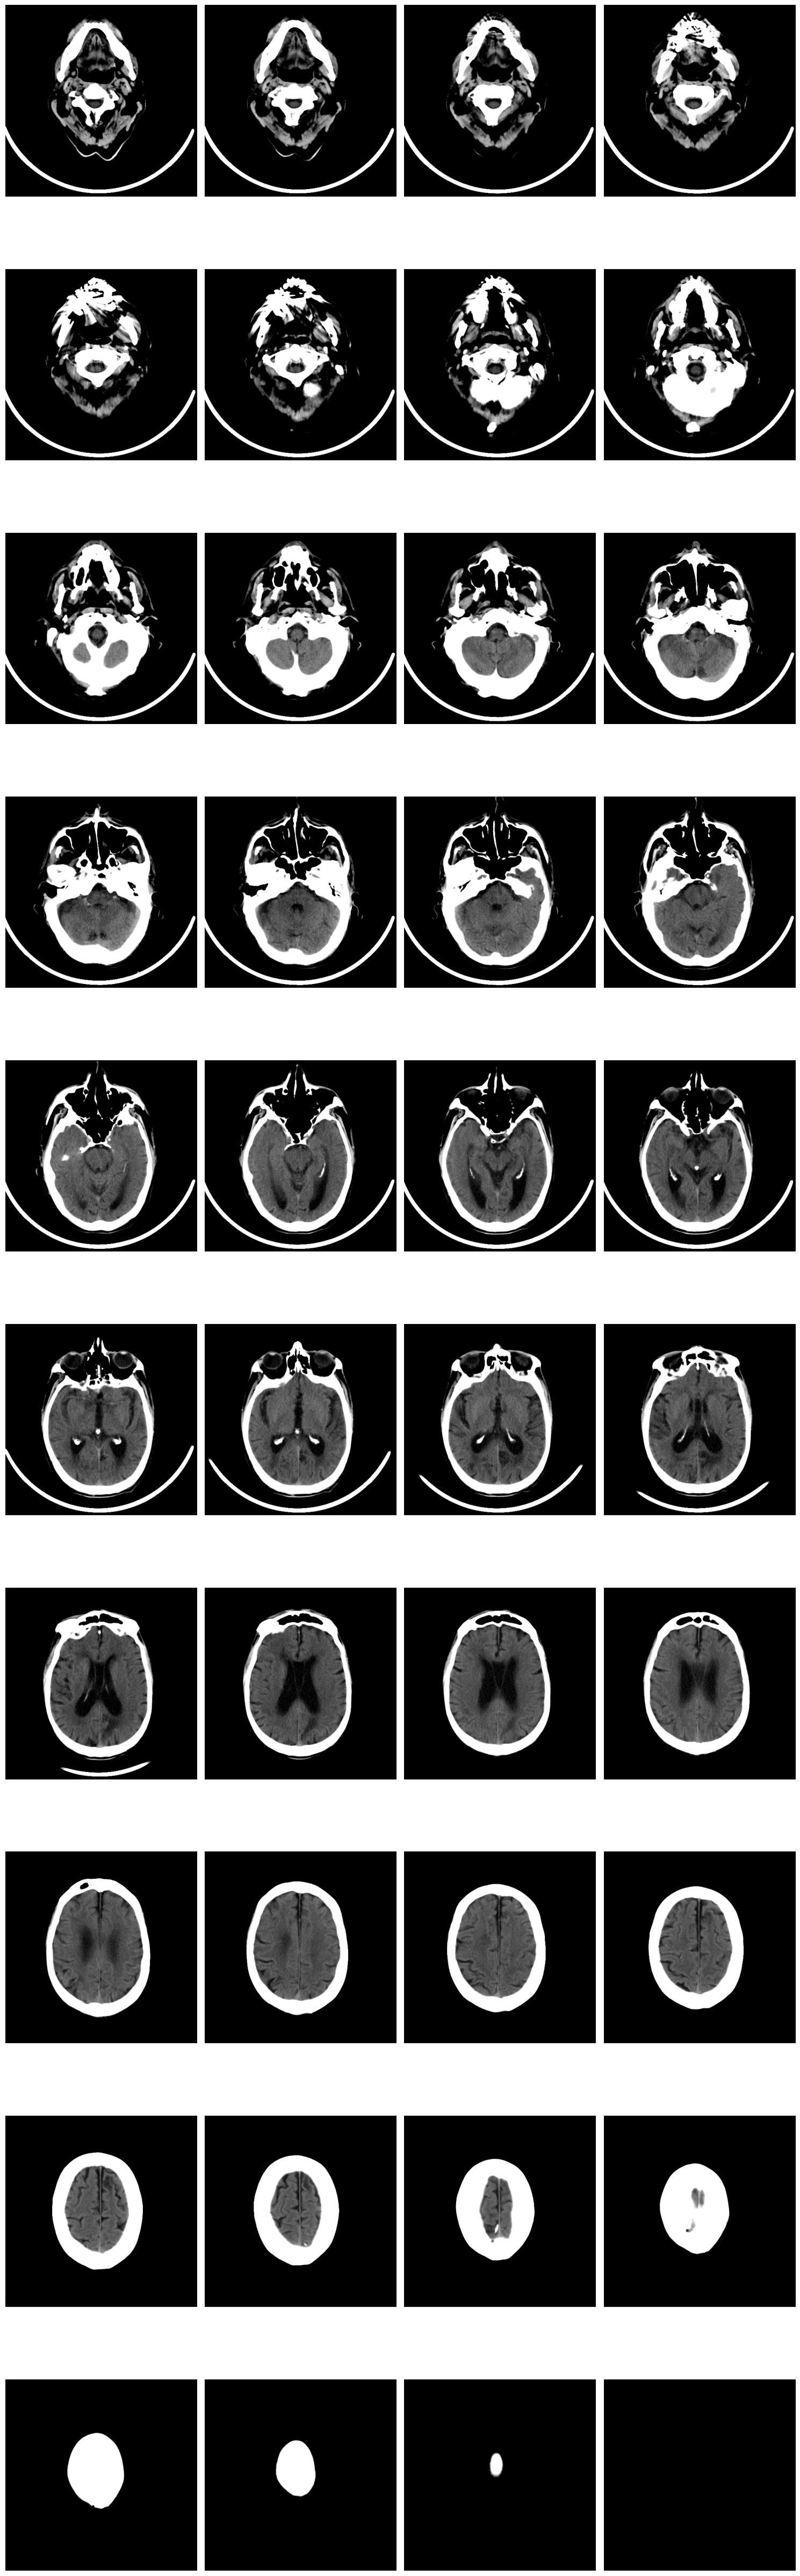

In [24]:
#show images for this patient
if dcm_files:
    n_images = 40
    n_cols = 4
    n_rows = (n_images + n_cols - 1) // n_cols  #ceiling division

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten()

    for i in range(n_images):
        file_path = RSNA_TRAIN_DIR / check_sample.iloc[i]['filename']
        ds = pydicom.dcmread(str(file_path))
        pixel_array = ds.pixel_array.astype(np.float32)
        
        #converts to Hounsfield Units
        hu = pixel_array * ds.RescaleSlope + ds.RescaleIntercept

        axes[i].imshow(hu, cmap='gray', vmin=0, vmax=80)
        #apparently they have ds.ImagePositionPatient metadata
        # axes[i].set_title(f'Patient: {ds.PatientID}[{i}] / {ds.StudyInstanceUID}\n{ds.ImagePositionPatient}, {ds.BitsStored}bit')
        axes[i].axis('off')

    #hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

So it is truly volumetric. But doesn't seems organised. The `ImagePositionPatient` has 3 values [x,y,z] and z is the order.

In [25]:
df.describe()

,ImagePositionZ,InstanceNumber
count,873945.000000,0.0
mean,168.720927,NaN
std,247.918089,NaN
min,-998.400024,NaN
25%,67.500000,NaN
50%,123.968000,NaN
75%,186.754776,NaN
max,1794.012760,NaN


Check if there are overlap patients (using `PatientID`) between train/test data to prevent data leak:

In [26]:
train_patients = set(df[df.split=='train']['PatientID'])
test_patients  = set(df[df.split=='test']['PatientID'])
print(f"Patient overlap between train and test: {len(train_patients & test_patients)}")

Patient overlap between train and test: 0


There is no data with same patientID across train/test dataset given by RSNA.

I need to check how many slices per study just for analysis..

Slices of - Train set -
count    21744.000000
mean        34.621183
std          5.095558
min         20.000000
25%         32.000000
50%         33.000000
75%         37.000000
max         60.000000
dtype: float64

Min:    20
Max:    60
Median: 33.0
Slices of - Test set -
count    3518.000000
mean       34.434906
std         4.981701
min        20.000000
25%        32.000000
50%        33.000000
75%        37.000000
max        60.000000
dtype: float64

Min:    20
Max:    60
Median: 33.0


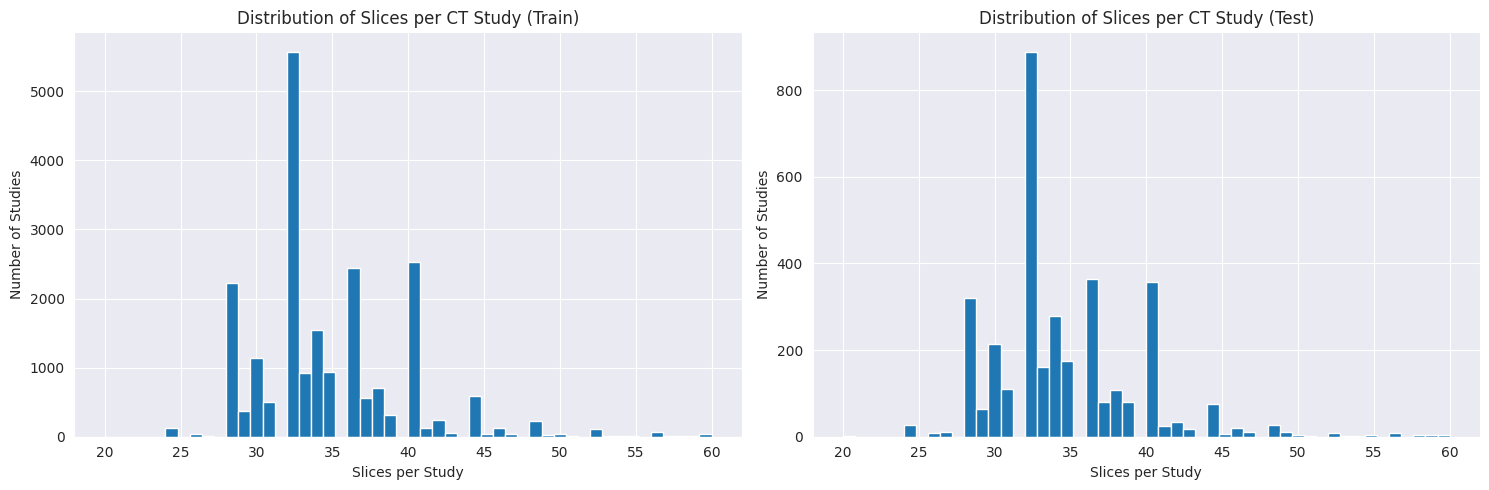

In [27]:
#check slices distribution
slices_per_study = {}
slices_per_study['train'] = df[df['split']=='train'].groupby('StudyInstanceUID').size()
slices_per_study['test'] = df[df['split']=='test'].groupby('StudyInstanceUID').size()

print("Slices of - Train set -")
print(slices_per_study['train'].describe())
print(f"\nMin:    {slices_per_study['train'].min()}")
print(f"Max:    {slices_per_study['train'].max()}")
print(f"Median: {slices_per_study['train'].median()}")

print("Slices of - Test set -")
print(slices_per_study['test'].describe())
print(f"\nMin:    {slices_per_study['test'].min()}")
print(f"Max:    {slices_per_study['test'].max()}")
print(f"Median: {slices_per_study['test'].median()}")

#plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

slices_per_study['train'].hist(bins=50, ax=axes[0])
axes[0].set_xlabel('Slices per Study')
axes[0].set_ylabel('Number of Studies')
axes[0].set_title('Distribution of Slices per CT Study (Train)')

slices_per_study['test'].hist(bins=50, ax=axes[1])
axes[1].set_xlabel('Slices per Study')
axes[1].set_ylabel('Number of Studies')
axes[1].set_title('Distribution of Slices per CT Study (Test)')

plt.tight_layout()
plt.savefig('slices_per_study_dist.png')
plt.show()

The distribution pretty similar. Majority from 28-40 slices per study.

Check empty values

### Physionet EDA

Check total slices and patients in Physionet dataset:

In [28]:
labels_physio_df = pd.read_csv(PHYSIONET_DIR / 'hemorrhage_diagnosis_raw_ct.csv')
print(f'Total slices labelled: {len(labels_physio_df)}')
print(f'Patients: {labels_physio_df["PatientNumber"].nunique()}')
print()

Total slices labelled: 2814
Patients: 75



Check distribution of data with/without brain hemorrhage:

In [29]:
has_hemorrhage = labels_physio_df['No_Hemorrhage'] == 0
print(f'Slices WITH hemorrhage: {has_hemorrhage.sum()} ({has_hemorrhage.mean()*100:.1f}%)')
print(f'Slices WITHOUT hemorrhage: {(~has_hemorrhage).sum()} ({(~has_hemorrhage).mean()*100:.1f}%)')
print()

Slices WITH hemorrhage: 318 (11.3%)
Slices WITHOUT hemorrhage: 2496 (88.7%)



Separate between all classes available:

In [30]:
subtypes = ['Intraventricular', 'Intraparenchymal', 'Subarachnoid', 'Epidural', 'Subdural']
print('Hemorrhage Subtype Counts (slice-level)')
for st in subtypes:
    count = labels_physio_df[st].sum()
    print(f'  {st}: {count} slices ({count/len(labels_physio_df)*100:.1f}%)')

Hemorrhage Subtype Counts (slice-level)
  Intraventricular: 24 slices (0.9%)
  Intraparenchymal: 73 slices (2.6%)
  Subarachnoid: 18 slices (0.6%)
  Epidural: 173 slices (6.1%)
  Subdural: 56 slices (2.0%)


Look at data shape:

In [31]:
#look at ONE scan
sample_patient = labels_physio_df[labels_physio_df['No_Hemorrhage'] == 0]['PatientNumber'].iloc[0]
print(f'Looking at patient {sample_patient}')

#load NIfTI
ct_nii = nib.load(str(PHYSIONET_DIR / 'ct_scans' / f'{sample_patient:03d}.nii'))
mask_nii = nib.load(str(PHYSIONET_DIR / 'masks' / f'{sample_patient:03d}.nii'))

ct_data = ct_nii.get_fdata() #hape: (H, W, num_slices)
mask_data = mask_nii.get_fdata()

print(f'CT shape: {ct_data.shape}')
print(f'Mask shape: {mask_data.shape}')
print(f'CT value range: [{ct_data.min():.0f}, {ct_data.max():.0f}] (Hounsfield Units)')
print(f'Mask unique values: {np.unique(mask_data)}')

Looking at patient 49


CT shape: (512, 512, 39)
Mask shape: (512, 512, 39)
CT value range: [-1024, 2914] (Hounsfield Units)
Mask unique values: [  0.         254.99999994]


Look at the data:

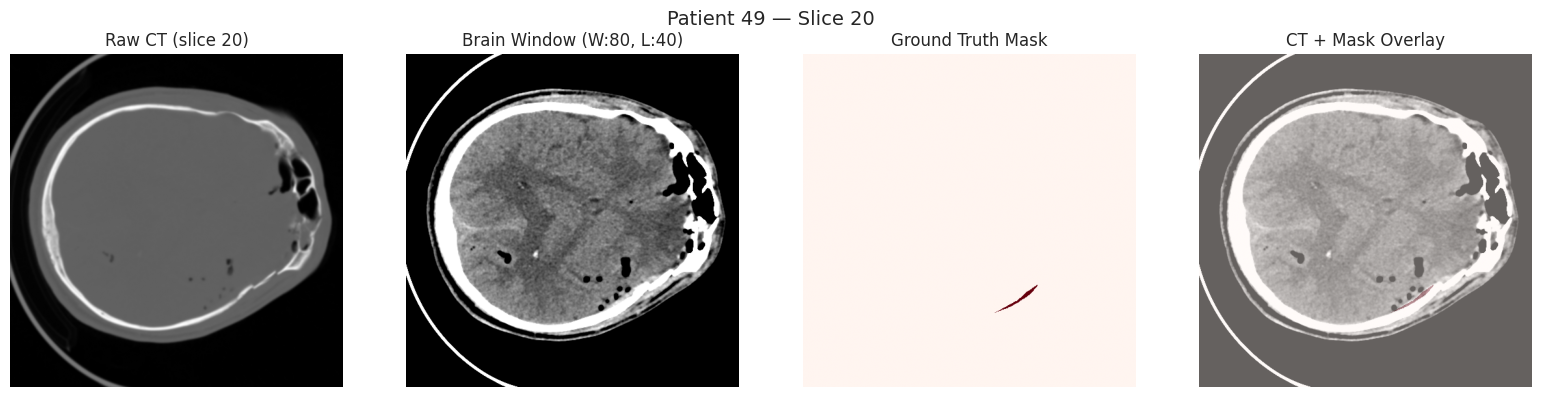

In [32]:
#find a slice that actually has blood in it
patient_labels = labels_physio_df[labels_physio_df['PatientNumber'] == sample_patient]
hemorrhage_slices = patient_labels[patient_labels['No_Hemorrhage'] == 0]['SliceNumber'].values
mid_slice = hemorrhage_slices[len(hemorrhage_slices)//2] - 1  # 0-indexed

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

#raw CT
axes[0].imshow(ct_data[:, :, mid_slice], cmap='gray')
axes[0].set_title(f'Raw CT (slice {mid_slice+1})')

#brain window (W:80, L:40)
brain_win = np.clip(ct_data[:, :, mid_slice], 0, 80) / 80
axes[1].imshow(brain_win, cmap='gray')
axes[1].set_title('Brain Window (W:80, L:40)')

#mask
axes[2].imshow(mask_data[:, :, mid_slice], cmap='Reds')
axes[2].set_title('Ground Truth Mask')

#overlay
axes[3].imshow(brain_win, cmap='gray')
axes[3].imshow(mask_data[:, :, mid_slice], cmap='Reds', alpha=0.4)
axes[3].set_title('CT + Mask Overlay')

for ax in axes:
    ax.axis('off')
plt.suptitle(f'Patient {sample_patient} — Slice {mid_slice+1}', fontsize=14)
plt.tight_layout()
plt.show()

## Preprocessing

Reshape lebel from RSNA to wide format:

In [33]:
# Split ID into slice ID and subtype
labels_rsna_df['SubType'] = labels_rsna_df['ID'].str.rsplit('_', n=1).str[-1]
labels_rsna_df['SliceID'] = labels_rsna_df['ID'].str.rsplit('_', n=1).str[0]

There is duplicate entries, check them:

In [34]:
dupes = labels_rsna_df[labels_rsna_df.duplicated(subset=['SliceID', 'SubType'], keep=False)]
print(f"Duplicate rows: {len(dupes)}")
print(dupes.head(12))

Duplicate rows: 48
                                  ID  Label           SubType       SliceID
56340          ID_a64d5deed_epidural      0          epidural  ID_a64d5deed
56341  ID_a64d5deed_intraparenchymal      0  intraparenchymal  ID_a64d5deed
56342  ID_a64d5deed_intraventricular      0  intraventricular  ID_a64d5deed
56343      ID_a64d5deed_subarachnoid      0      subarachnoid  ID_a64d5deed
56344          ID_a64d5deed_subdural      0          subdural  ID_a64d5deed
56345               ID_a64d5deed_any      0               any  ID_a64d5deed
56346          ID_a64d5deed_epidural      0          epidural  ID_a64d5deed
56347  ID_a64d5deed_intraparenchymal      0  intraparenchymal  ID_a64d5deed
56348  ID_a64d5deed_intraventricular      0  intraventricular  ID_a64d5deed
56349      ID_a64d5deed_subarachnoid      0      subarachnoid  ID_a64d5deed
56350          ID_a64d5deed_subdural      0          subdural  ID_a64d5deed
56351               ID_a64d5deed_any      0               any  ID_a64

Drop it:

In [35]:
labels_rsna_df = labels_rsna_df.drop_duplicates(subset=['SliceID', 'SubType'], keep='first')

In [36]:
#pivot to wide format
labels_wide = labels_rsna_df.pivot(index='SliceID', columns='SubType', values='Label').reset_index()

#reorder columns
label_cols = ['epidural', 'intraparenchymal', 'intraventricular', 'subarachnoid', 'subdural', 'any']
labels_wide = labels_wide[['SliceID'] + label_cols]

print(labels_wide.head())
print(f"Total slices: {len(labels_wide)}")
print(f"Hemorrhage positive: {labels_wide['any'].sum()}")

SubType       SliceID  epidural  intraparenchymal  intraventricular  \
0        ID_000012eaf         0                 0                 0   
1        ID_000039fa0         0                 0                 0   
2        ID_00005679d         0                 0                 0   
3        ID_00008ce3c         0                 0                 0   
4        ID_0000950d7         0                 0                 0   

SubType  subarachnoid  subdural  any  
0                   0         0    0  
1                   0         0    0  
2                   0         0    0  
3                   0         0    0  
4                   0         0    0  
Total slices: 752803
Hemorrhage positive: 107933


In [37]:
df

,filename,split,PatientID,StudyInstanceUID,SeriesInstanceUID,SOPInstanceUID,ImagePositionZ,InstanceNumber
0,ID_69e273863.dcm,train,ID_048703f5,ID_5c33a2b716,ID_9bb83869e0,ID_69e273863,205.099976,NaN
1,ID_4ff13f8b1.dcm,train,ID_9eb32732,ID_d7a634ec77,ID_17f87147e0,ID_4ff13f8b1,176.000000,NaN
2,ID_0ad9fea38.dcm,train,ID_d7d213a6,ID_7fdbd503f9,ID_150c867a28,ID_0ad9fea38,173.129415,NaN
3,ID_440562517.dcm,train,ID_3c45cca3,ID_7b72f23129,ID_443e596744,ID_440562517,87.161957,NaN
4,ID_92c893a0e.dcm,train,ID_c23b7634,ID_b240bf301a,ID_bb02db43f0,ID_92c893a0e,995.000031,NaN
...,...,...,...,...,...,...,...,...
873940,ID_4c2f12bfa.dcm,test,ID_d55976c9,ID_46ddfdeba5,ID_62b80b67d5,ID_4c2f12bfa,182.224733,NaN
873941,ID_944003c35.dcm,test,ID_0d6bf43e,ID_c7dd05fb83,ID_ae78750e67,ID_944003c35,-76.500000,NaN
873942,ID_2ae7700b7.dcm,test,ID_84ad715b,ID_33a55abe8e,ID_be04134a27,ID_2ae7700b7,108.300049,NaN
873943,ID_a37c4963f.dcm,test,ID_64423c34,ID_1f94267dbb,ID_ef7c5b2884,ID_a37c4963f,51.000000,NaN


`RSNA_TEST_DIR` HAS NO LABEL/ground truth, so I can't use them. Therefore, for the training, I need to split them all.

In [38]:

dicom_index = df
#only select from original train dataset
dicom_index = dicom_index[dicom_index['split'] == 'train']

#merge with labels to get PatientID per slice
labels_wide['filename'] = labels_wide['SliceID'] + '.dcm'
labels_with_patient = labels_wide.merge(dicom_index[['filename', 'PatientID']], on='filename', how='left')

#split by patient, not by slice
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(labels_with_patient, groups=labels_with_patient['PatientID']))

train_df = labels_with_patient.iloc[train_idx]
test_df = labels_with_patient.iloc[test_idx]

#verify no overlap
train_patients = set(train_df['PatientID'])
test_patients = set(test_df['PatientID'])
print(f"Train-Test patient overlap: {len(train_patients & test_patients)}")
print(f"Train slices: {len(train_df)}, Test slices: {len(test_df)}")

Train-Test patient overlap: 0
Train slices: 602342, Test slices: 150461


In [39]:
train_df

,SliceID,epidural,intraparenchymal,intraventricular,subarachnoid,subdural,any,filename,PatientID
0,ID_000012eaf,0,0,0,0,0,0,ID_000012eaf.dcm,ID_f15c0eee
1,ID_000039fa0,0,0,0,0,0,0,ID_000039fa0.dcm,ID_eeaf99e7
2,ID_00005679d,0,0,0,0,0,0,ID_00005679d.dcm,ID_18f2d431
3,ID_00008ce3c,0,0,0,0,0,0,ID_00008ce3c.dcm,ID_ce8a3cd2
5,ID_0000aee4b,0,0,0,0,0,0,ID_0000aee4b.dcm,ID_ce5f0b6c
...,...,...,...,...,...,...,...,...,...
752798,ID_ffff82e46,0,0,0,0,0,0,ID_ffff82e46.dcm,ID_a85c9d08
752799,ID_ffff922b9,0,0,1,0,0,1,ID_ffff922b9.dcm,ID_5964c5e5
752800,ID_ffffb670a,0,0,0,1,0,1,ID_ffffb670a.dcm,ID_4f7414e4
752801,ID_ffffcbff8,0,0,0,0,0,0,ID_ffffcbff8.dcm,ID_a5382712


Set the random seed to allow reproducibiliy of the research before preprocessing:

In [40]:
#seed
SEED = 20260605
def change_seed(SEED=42):
    #lock python and libraries random generator to make sure reproducibility
    os.environ['PYTHONHASHSEED'] = str(SEED)
    random.seed(SEED)
    np.random.seed(SEED)
    tf.random.set_seed(SEED)
change_seed(SEED) #using the assigned seed

In [ ]:
def load_dicom_as_array(filepath, img_size):
    ds = pydicom.dcmread(str(filepath))
    pixel_array = ds.pixel_array.astype(np.float32)
    
    # Convert to Hounsfield Units
    hu = pixel_array * ds.RescaleSlope + ds.RescaleIntercept
    
    # Brain window (center=40, width=80) range [0, 80]
    hu = np.clip(hu, 0, 80)
    
    # Normalize to [0, 1]
    hu = hu / 80.0
    
    #resize
    hu = resize(hu, (img_size, img_size), anti_aliasing=True)
    
    return hu

#load  all slices for selected patients
def load_from_df(df):
    images, labels, missing = [], [], 0
    for _, row in df.iterrows():
        dcm_path = RSNA_TRAIN_DIR / row['filename']
        if dcm_path.exists():
            #downsampling to 256x256 image size
            img = load_dicom_as_array(dcm_path, img_size=256)
            images.append(img)
            labels.append(row[label_cols].values.astype(np.float32))
        else:
            missing += 1
    print(f"Loaded: {len(images)}, Missing: {missing}")
    return np.array(images)[..., np.newaxis], np.array(labels)

#select 100 patients for first try
N_TRAIN_PATIENTS = 800
N_TEST_PATIENTS = 200

train_patients_sample = train_df['PatientID'].unique()[:N_TRAIN_PATIENTS]
test_patients_sample = test_df['PatientID'].unique()[:N_TEST_PATIENTS]

train_sample = train_df[train_df['PatientID'].isin(train_patients_sample)]
test_sample = test_df[test_df['PatientID'].isin(test_patients_sample)]

print(f"Train: {len(train_sample)} slices from {N_TRAIN_PATIENTS} patients")
print(f"Test: {len(test_sample)} slices from {N_TEST_PATIENTS} patients")

#cache to save preprocessed in later run
CACHE_DIR = Path(os.environ['KAGGLEHUB_CACHE']) / 'preprocessed'
CACHE_DIR.mkdir(parents=True, exist_ok=True)

cache_file = CACHE_DIR / f'rsna_train{N_TRAIN_PATIENTS}_test{N_TEST_PATIENTS}_256.npz'

if cache_file.exists():
    print(f"Loading from cache: {cache_file}")
    data = np.load(cache_file)
    x_train, y_train = data['x_train'], data['y_train']
    x_test, y_test = data['x_test'], data['y_test']
else:
    print("Processing DICOMs...")
    x_train, y_train = load_from_df(train_sample)
    x_test, y_test = load_from_df(test_sample)
    
    print(f"Saving to cache: {cache_file}")
    np.savez(cache_file, x_train=x_train, y_train=y_train, x_test=x_test, y_test=y_test)

print(f"x_train: {x_train.shape}, y_train: {y_train.shape}")
print(f"x_test: {x_test.shape}, y_test: {y_test.shape}")

Train: 40686 slices from 800 patients
Test: 9335 slices from 200 patients
Loaded: 40686, Missing: 0
Loaded: 9335, Missing: 0
x_train: (40686, 256, 256, 1), y_train: (40686, 6)
x_test: (9335, 256, 256, 1), y_test: (9335, 6)


forgot to cached:

In [ ]:
# CACHE_DIR = Path(os.environ['KAGGLEHUB_CACHE']) / 'preprocessed'
# CACHE_DIR.mkdir(parents=True, exist_ok=True)
# cache_file = CACHE_DIR / f'rsna_train{N_TRAIN_PATIENTS}_test{N_TEST_PATIENTS}_256.npz'

# np.savez(cache_file, x_train=x_train, y_train=y_train, x_test=x_test, y_test=y_test)
# print(f"Saved to {cache_file}")

Saved to /rds/projects/k/karwatha-karwath-hds-pg-research/axr1222/data/preprocessed/rsna_train800_test200_256.npz


In [42]:
print("Train label distribution:")
print(y_train.sum(axis=0))
print(f"Train hemorrhage rate: {y_train[:, 5].mean():.2%}")

print("\nTest label distribution:")
print(y_test.sum(axis=0))
print(f"Test hemorrhage rate: {y_test[:, 5].mean():.2%}")

Train label distribution:
[ 134. 2077. 1467. 2630. 2298. 6303.]
Train hemorrhage rate: 15.49%

Test label distribution:
[  24.  396.  273.  424.  746. 1390.]
Test hemorrhage rate: 14.89%


In [43]:
#verify no patient overlap
print(f"Patient overlap: {len(set(train_patients_sample) & set(test_patients_sample))}")

#label distribution
print(f"\nTrain hemorrhage rate: {y_train[:, 5].mean():.2%}")
print(f"Test hemorrhage rate:  {y_test[:, 5].mean():.2%}")

#per-type breakdown
for i, col in enumerate(label_cols):
    print(f"  {col:25s} train: {y_train[:, i].mean():.2%}  test: {y_test[:, i].mean():.2%}")

Patient overlap: 0

Train hemorrhage rate: 15.49%
Test hemorrhage rate:  14.89%
  epidural                  train: 0.33%  test: 0.26%
  intraparenchymal          train: 5.10%  test: 4.24%
  intraventricular          train: 3.61%  test: 2.92%
  subarachnoid              train: 6.46%  test: 4.54%
  subdural                  train: 5.65%  test: 7.99%
  any                       train: 15.49%  test: 14.89%


check total NOT sample:

In [44]:
print(f"Total train slices available: {len(train_df)}")
print(f"Total train patients: {train_df['PatientID'].nunique()}")
print(f"Avg slices per patient: {len(train_df) / train_df['PatientID'].nunique():.0f}")

Total train slices available: 602342
Total train patients: 15150
Avg slices per patient: 40


traing

In [46]:
def getModel(filters1=16, filters2=32, filters3=64,
             lr=0.0001, layer_number=3, dropoutrate=0.3):
    
    img_dimension = (256, 256, 1)

    cnn = models.Sequential()
    cnn.add(layers.Input(img_dimension))

    cnn.add(layers.Conv2D(filters=filters1, kernel_size=(3, 3), padding='same'))
    cnn.add(layers.BatchNormalization())
    cnn.add(layers.Activation('relu'))
    cnn.add(layers.MaxPooling2D(pool_size=(2, 2)))
    cnn.add(layers.Dropout(dropoutrate))

    if layer_number >= 2:
        cnn.add(layers.Conv2D(filters=filters2, kernel_size=(3, 3), padding='same'))
        cnn.add(layers.BatchNormalization())
        cnn.add(layers.Activation('relu'))
        cnn.add(layers.MaxPooling2D(pool_size=(2, 2)))
        cnn.add(layers.Dropout(dropoutrate))

    if layer_number >= 3:
        cnn.add(layers.Conv2D(filters=filters3, kernel_size=(3, 3), padding='same'))
        cnn.add(layers.BatchNormalization())
        cnn.add(layers.Activation('relu'))
        cnn.add(layers.MaxPooling2D(pool_size=(2, 2)))
        cnn.add(layers.Dropout(dropoutrate))

    cnn.add(layers.Flatten())
    cnn.add(layers.Dense(128, activation='relu'))  # relu, not sigmoid
    cnn.add(layers.Dropout(dropoutrate))
    cnn.add(layers.Dense(6, activation='sigmoid'))

    cnn.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['recall', tf.keras.metrics.AUC(name='auc', multi_label=True)]
    )
    return cnn


clf = KerasClassifier(
    model=getModel,
    validation_split=0.15,
    callbacks=[callbacks.EarlyStopping(
        monitor='val_auc',
        patience=5,
        mode='max',
        restore_best_weights=True
    )]
)

pipe = Pipeline([
    ('clf', clf),
])

# Sample weights based on 'any' hemorrhage column
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight('balanced', y_train[:, 5])

param_grid = [
    {
        'clf__model__filters1': [16],
        'clf__model__filters2': [32],
        'clf__model__filters3': [128, 256],
        'clf__model__lr': [0.0001],
        'clf__model__layer_number': [3],
        'clf__model__dropoutrate': [0.25],
        'clf__epochs': [20],
        'clf__batch_size': [32],
    },
]

def multi_label_auc(y_true, y_pred, **kwargs):
    return roc_auc_score(y_true, y_pred, average='weighted', multi_class='ovr')

roc_auc = make_scorer(multi_label_auc)

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring=roc_auc,
    cv=MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=1,
    error_score='raise',
    verbose=1
)

started = datetime.datetime.now()
grid.fit(x_train, y_train.astype(int), clf__sample_weight=sample_weights)
finished = datetime.datetime.now()
total = finished - started
m, s = divmod(total.total_seconds(), 60)
print(f"Total time: {int(m)}m {int(s)}s")

Fitting 5 folds for each of 2 candidates, totalling 10 fits


I0000 00:00:1779202818.130986 3631767 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38479 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:ca:00.0, compute capability: 8.0


Epoch 1/20


I0000 00:00:1779202832.507641 3696492 service.cc:153] XLA service 0x7fb14c037e20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779202832.507665 3696492 service.cc:161]   StreamExecutor [0]: NVIDIA A100-SXM4-40GB, Compute Capability 8.0 (Driver: 13.0.0; Runtime: 12.6.0; Toolkit: 12.5.0; DNN: 9.8.0)
I0000 00:00:1779202832.579356 3696492 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1779202832.985881 3696492 cuda_dnn.cc:461] Loaded cuDNN version 90800
I0000 00:00:1779202833.115153 3696492 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4328__.62


 17/865 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - auc: 0.4400 - loss: 1.7363 - recall: 0.3288  

I0000 00:00:1779202845.947677 3696492 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


863/865 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - auc: 0.6316 - loss: 0.5771 - recall: 0.3649

I0000 00:00:1779202854.760019 3696490 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4328__.62


865/865 ━━━━━━━━━━━━━━━━━━━━ 39s 27ms/step - auc: 0.6750 - loss: 0.4680 - recall: 0.3788 - val_auc: 0.7641 - val_loss: 0.4316 - val_recall: 0.4263
Epoch 2/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - auc: 0.7315 - loss: 0.4071 - recall: 0.3802 - val_auc: 0.8021 - val_loss: 0.3985 - val_recall: 0.3950
Epoch 3/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - auc: 0.7568 - loss: 0.3927 - recall: 0.3837 - val_auc: 0.7993 - val_loss: 0.4033 - val_recall: 0.4058
Epoch 4/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - auc: 0.7824 - loss: 0.3796 - recall: 0.3829 - val_auc: 0.8253 - val_loss: 0.3920 - val_recall: 0.4096
Epoch 5/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - auc: 0.7763 - loss: 0.3774 - recall: 0.3992 - val_auc: 0.8104 - val_loss: 0.4160 - val_recall: 0.3999
Epoch 6/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - auc: 0.8016 - loss: 0.3667 - recall: 0.3972 - val_auc: 0.8279 - val_loss: 0.3865 - val_recall: 0.3999
Epoch 7/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - auc: 0.8159 -

I0000 00:00:1779203063.883274 3696493 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_116889__.62


862/865 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - auc: 0.6354 - loss: 0.6252 - recall: 0.3309

I0000 00:00:1779203076.338347 3696494 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_116889__.62


865/865 ━━━━━━━━━━━━━━━━━━━━ 28s 25ms/step - auc: 0.6804 - loss: 0.4799 - recall: 0.3451 - val_auc: 0.7968 - val_loss: 0.4346 - val_recall: 0.4155
Epoch 2/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - auc: 0.7382 - loss: 0.4027 - recall: 0.3697 - val_auc: 0.8158 - val_loss: 0.4000 - val_recall: 0.4426
Epoch 3/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - auc: 0.7537 - loss: 0.3973 - recall: 0.3388 - val_auc: 0.8190 - val_loss: 0.3965 - val_recall: 0.3776
Epoch 4/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - auc: 0.7671 - loss: 0.3783 - recall: 0.3570 - val_auc: 0.8214 - val_loss: 0.3929 - val_recall: 0.4269
Epoch 5/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - auc: 0.7838 - loss: 0.3720 - recall: 0.3555 - val_auc: 0.8445 - val_loss: 0.3676 - val_recall: 0.2985
Epoch 6/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - auc: 0.8037 - loss: 0.3640 - recall: 0.3685 - val_auc: 0.8491 - val_loss: 0.3601 - val_recall: 0.3971
Epoch 7/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - auc: 0.8122 -

I0000 00:00:1779203282.790706 3696491 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_229538__.62


862/865 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - auc: 0.6534 - loss: 0.6384 - recall: 0.3112

I0000 00:00:1779203295.289436 3696493 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_229538__.62


865/865 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - auc: 0.6869 - loss: 0.4793 - recall: 0.3171 - val_auc: 0.7367 - val_loss: 0.4614 - val_recall: 0.4020
Epoch 2/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - auc: 0.7281 - loss: 0.4105 - recall: 0.3177 - val_auc: 0.7573 - val_loss: 0.4572 - val_recall: 0.3798
Epoch 3/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - auc: 0.7433 - loss: 0.4001 - recall: 0.3260 - val_auc: 0.6745 - val_loss: 0.4664 - val_recall: 0.4184
Epoch 4/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - auc: 0.7561 - loss: 0.3953 - recall: 0.3330 - val_auc: 0.7659 - val_loss: 0.4306 - val_recall: 0.3983
Epoch 5/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - auc: 0.7668 - loss: 0.3877 - recall: 0.3259 - val_auc: 0.7723 - val_loss: 0.4371 - val_recall: 0.4131
Epoch 6/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - auc: 0.7857 - loss: 0.3803 - recall: 0.3275 - val_auc: 0.7523 - val_loss: 0.4565 - val_recall: 0.4110
Epoch 7/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - auc: 0.7883 -

I0000 00:00:1779203495.047831 3696494 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_341967__.62


861/865 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - auc: 0.6438 - loss: 0.6332 - recall: 0.1349

I0000 00:00:1779203507.531685 3696490 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_341967__.62


865/865 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - auc: 0.6758 - loss: 0.5031 - recall: 0.1032 - val_auc: 0.7855 - val_loss: 0.4460 - val_recall: 0.0237
Epoch 2/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - auc: 0.7254 - loss: 0.4261 - recall: 0.1982 - val_auc: 0.7834 - val_loss: 0.4353 - val_recall: 0.3671
Epoch 3/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - auc: 0.7458 - loss: 0.4067 - recall: 0.3329 - val_auc: 0.7835 - val_loss: 0.4402 - val_recall: 0.3892
Epoch 4/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - auc: 0.7607 - loss: 0.3973 - recall: 0.3157 - val_auc: 0.7890 - val_loss: 0.4168 - val_recall: 0.3865
Epoch 5/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - auc: 0.7726 - loss: 0.3872 - recall: 0.3127 - val_auc: 0.7829 - val_loss: 0.4021 - val_recall: 0.4102
Epoch 6/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - auc: 0.7870 - loss: 0.3795 - recall: 0.3158 - val_auc: 0.8241 - val_loss: 0.3883 - val_recall: 0.3930
Epoch 7/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - auc: 0.7963 -

I0000 00:00:1779203708.059576 3696491 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_454264__.62


860/865 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - auc: 0.6311 - loss: 0.6250 - recall: 0.3338

I0000 00:00:1779203720.627997 3696490 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_454264__.62


865/865 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - auc: 0.6674 - loss: 0.4968 - recall: 0.3259 - val_auc: 0.7740 - val_loss: 0.4389 - val_recall: 0.1997
Epoch 2/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - auc: 0.7354 - loss: 0.4131 - recall: 0.3079 - val_auc: 0.7963 - val_loss: 0.4021 - val_recall: 0.3207
Epoch 3/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - auc: 0.7603 - loss: 0.3946 - recall: 0.3095 - val_auc: 0.7875 - val_loss: 0.4136 - val_recall: 0.3662
Epoch 4/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - auc: 0.7791 - loss: 0.3816 - recall: 0.3002 - val_auc: 0.7921 - val_loss: 0.4150 - val_recall: 0.3887
Epoch 5/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - auc: 0.7953 - loss: 0.3703 - recall: 0.3101 - val_auc: 0.8115 - val_loss: 0.3998 - val_recall: 0.3828
Epoch 6/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - auc: 0.8129 - loss: 0.3660 - recall: 0.3288 - val_auc: 0.8239 - val_loss: 0.4034 - val_recall: 0.3646
Epoch 7/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - auc: 0.8213 -

I0000 00:00:1779203919.866549 3696494 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_566781__.62


860/865 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - auc: 0.5751 - loss: 0.7948 - recall: 0.3564

I0000 00:00:1779203937.399450 3696489 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_566781__.62


865/865 ━━━━━━━━━━━━━━━━━━━━ 31s 25ms/step - auc: 0.5918 - loss: 0.5818 - recall: 0.3231 - val_auc: 0.6572 - val_loss: 0.5178 - val_recall: 0.4171
Epoch 2/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - auc: 0.6242 - loss: 0.4780 - recall: 0.1031 - val_auc: 0.7926 - val_loss: 0.4766 - val_recall: 0.0000e+00
Epoch 3/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - auc: 0.6673 - loss: 0.4567 - recall: 0.0681 - val_auc: 0.7996 - val_loss: 0.4714 - val_recall: 0.0753
Epoch 4/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - auc: 0.6754 - loss: 0.4479 - recall: 0.1229 - val_auc: 0.7881 - val_loss: 0.4450 - val_recall: 0.0759
Epoch 5/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - auc: 0.6766 - loss: 0.4434 - recall: 0.1432 - val_auc: 0.7930 - val_loss: 0.4456 - val_recall: 0.1733
Epoch 6/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - auc: 0.6892 - loss: 0.4336 - recall: 0.1549 - val_auc: 0.8269 - val_loss: 0.4332 - val_recall: 0.2363
Epoch 7/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - auc

I0000 00:00:1779204081.903357 3696491 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_631779__.62


862/865 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - auc: 0.5978 - loss: 0.7173 - recall: 0.3353

I0000 00:00:1779204096.768578 3696492 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_631779__.62


865/865 ━━━━━━━━━━━━━━━━━━━━ 27s 24ms/step - auc: 0.6339 - loss: 0.5136 - recall: 0.3134 - val_auc: 0.7834 - val_loss: 0.4121 - val_recall: 0.3207
Epoch 2/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - auc: 0.6794 - loss: 0.4634 - recall: 0.1271 - val_auc: 0.8030 - val_loss: 0.4464 - val_recall: 0.0634
Epoch 3/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - auc: 0.6776 - loss: 0.4520 - recall: 0.1296 - val_auc: 0.8179 - val_loss: 0.4176 - val_recall: 0.0390
Epoch 4/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - auc: 0.7055 - loss: 0.4376 - recall: 0.1511 - val_auc: 0.8289 - val_loss: 0.4422 - val_recall: 0.3034
Epoch 5/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - auc: 0.7265 - loss: 0.4240 - recall: 0.1816 - val_auc: 0.8369 - val_loss: 0.4401 - val_recall: 0.3738
Epoch 6/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - auc: 0.7596 - loss: 0.4073 - recall: 0.2175 - val_auc: 0.8384 - val_loss: 0.4008 - val_recall: 0.3548
Epoch 7/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - auc: 0.

I0000 00:00:1779204337.624000 3696493 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_744340__.62


864/865 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - auc: 0.6298 - loss: 0.8502 - recall: 0.2026

I0000 00:00:1779204352.516910 3696489 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_744340__.62


865/865 ━━━━━━━━━━━━━━━━━━━━ 25s 21ms/step - auc: 0.6661 - loss: 0.5463 - recall: 0.2022 - val_auc: 0.7755 - val_loss: 0.4456 - val_recall: 0.3043
Epoch 2/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - auc: 0.6966 - loss: 0.4381 - recall: 0.2623 - val_auc: 0.7981 - val_loss: 0.4274 - val_recall: 0.1939
Epoch 3/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - auc: 0.7093 - loss: 0.4298 - recall: 0.2674 - val_auc: 0.8011 - val_loss: 0.4351 - val_recall: 0.3265
Epoch 4/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - auc: 0.7374 - loss: 0.4173 - recall: 0.3152 - val_auc: 0.7973 - val_loss: 0.4303 - val_recall: 0.3962
Epoch 5/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - auc: 0.7478 - loss: 0.4066 - recall: 0.3700 - val_auc: 0.8068 - val_loss: 0.4118 - val_recall: 0.4010
Epoch 6/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - auc: 0.7544 - loss: 0.4031 - recall: 0.3868 - val_auc: 0.8188 - val_loss: 0.4205 - val_recall: 0.4168
Epoch 7/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - auc: 0.

I0000 00:00:1779204591.278372 3696493 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_856813__.62


863/865 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - auc: 0.6260 - loss: 0.8498 - recall: 0.3353

I0000 00:00:1779204606.221916 3696489 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_856813__.62


865/865 ━━━━━━━━━━━━━━━━━━━━ 25s 21ms/step - auc: 0.6505 - loss: 0.5576 - recall: 0.3431 - val_auc: 0.7567 - val_loss: 0.4319 - val_recall: 0.5111
Epoch 2/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - auc: 0.6982 - loss: 0.4400 - recall: 0.3530 - val_auc: 0.7766 - val_loss: 0.4124 - val_recall: 0.3116
Epoch 3/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - auc: 0.7133 - loss: 0.4193 - recall: 0.3273 - val_auc: 0.7739 - val_loss: 0.4158 - val_recall: 0.3730
Epoch 4/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - auc: 0.7346 - loss: 0.4097 - recall: 0.3281 - val_auc: 0.7923 - val_loss: 0.4239 - val_recall: 0.3606
Epoch 5/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - auc: 0.7490 - loss: 0.4026 - recall: 0.3241 - val_auc: 0.7860 - val_loss: 0.4011 - val_recall: 0.3504
Epoch 6/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - auc: 0.7634 - loss: 0.3967 - recall: 0.3148 - val_auc: 0.8031 - val_loss: 0.4153 - val_recall: 0.3989
Epoch 7/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - auc: 0.

I0000 00:00:1779204844.178561 3696489 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_969154__.62


862/865 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - auc: 0.6026 - loss: 0.8674 - recall: 0.2565

I0000 00:00:1779204859.047804 3696491 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_969154__.62


865/865 ━━━━━━━━━━━━━━━━━━━━ 25s 21ms/step - auc: 0.6315 - loss: 0.6117 - recall: 0.2197 - val_auc: 0.6978 - val_loss: 0.6180 - val_recall: 0.3817
Epoch 2/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - auc: 0.6656 - loss: 0.4807 - recall: 0.1441 - val_auc: 0.7892 - val_loss: 0.4606 - val_recall: 0.0519
Epoch 3/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - auc: 0.6764 - loss: 0.4522 - recall: 0.1360 - val_auc: 0.7744 - val_loss: 0.4854 - val_recall: 0.2666
Epoch 4/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - auc: 0.6879 - loss: 0.4437 - recall: 0.1555 - val_auc: 0.7800 - val_loss: 0.4608 - val_recall: 0.2543
Epoch 5/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - auc: 0.6933 - loss: 0.4359 - recall: 0.1747 - val_auc: 0.7569 - val_loss: 0.4627 - val_recall: 0.2880
Epoch 6/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - auc: 0.6966 - loss: 0.4304 - recall: 0.1910 - val_auc: 0.7730 - val_loss: 0.4922 - val_recall: 0.3881
Epoch 7/20
865/865 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - auc: 0.

I0000 00:00:1779204955.025607 3696490 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1013140__.62


1076/1081 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - auc: 0.6413 - loss: 0.5636 - recall: 0.3700

I0000 00:00:1779204969.619114 3696491 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1013140__.62


1081/1081 ━━━━━━━━━━━━━━━━━━━━ 31s 23ms/step - auc: 0.6669 - loss: 0.4635 - recall: 0.3706 - val_auc: 0.7560 - val_loss: 0.4151 - val_recall: 0.4486
Epoch 2/20
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - auc: 0.7166 - loss: 0.4097 - recall: 0.4023 - val_auc: 0.7873 - val_loss: 0.3970 - val_recall: 0.4306
Epoch 3/20
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - auc: 0.7452 - loss: 0.3941 - recall: 0.3284 - val_auc: 0.8119 - val_loss: 0.3965 - val_recall: 0.4009
Epoch 4/20
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - auc: 0.7681 - loss: 0.3862 - recall: 0.3095 - val_auc: 0.8296 - val_loss: 0.3871 - val_recall: 0.3575
Epoch 5/20
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - auc: 0.7836 - loss: 0.3800 - recall: 0.3092 - val_auc: 0.8187 - val_loss: 0.3985 - val_recall: 0.3906
Epoch 6/20
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - auc: 0.7982 - loss: 0.3729 - recall: 0.3116 - val_auc: 0.8442 - val_loss: 0.3973 - val_recall: 0.4027
Epoch 7/20
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/

In [47]:
print (f'Grid Search started at {started}\n and finished at {finished}')
print(f"\nTotal time (H:m:s): {m//60:.0f}:{m%60:02.0f}:{s:02.1f}")
print("\nBest params:", grid.best_params_)
print("\nBest CV score:", grid.best_score_)



Grid Search started at 2026-05-19 16:00:10.246421
 and finished at 2026-05-19 16:39:54.175652

Total time (H:m:s): 0:39:43.9

Best params: {'clf__batch_size': 32, 'clf__epochs': 20, 'clf__model__dropoutrate': 0.25, 'clf__model__filters1': 16, 'clf__model__filters2': 32, 'clf__model__filters3': 128, 'clf__model__layer_number': 3, 'clf__model__lr': 0.0001}

Best CV score: 0.6465236249882099


In [48]:

joblib.dump(grid.best_estimator_, "model_newww1.pkl", compress=1)
print("✅ Exported without retraining")

✅ Exported without retraining


In [49]:
# export h5
keras_model = grid.best_estimator_.named_steps['clf'].model_
keras_model.save("rsna_model_1142_auc.h5")
print(f"✅ Model exported")

✅ Model exported


In [50]:
results = pd.DataFrame(grid.cv_results_)
results.sort_values("mean_test_score", ascending=False)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_clf__batch_size,param_clf__epochs,param_clf__model__dropoutrate,param_clf__model__filters1,param_clf__model__filters2,param_clf__model__filters3,...,param_clf__model__lr,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,213.425220,7.199883,4.423973,0.659742,32,20,0.25,16,32,128,...,0.0001,"{'clf__batch_size': 32, 'clf__epochs': 20, 'cl...",0.666404,0.649988,0.614226,0.641734,0.660266,0.646524,0.018233,1
1,202.714649,59.310103,4.435463,0.448459,32,20,0.25,16,32,256,...,0.0001,"{'clf__batch_size': 32, 'clf__epochs': 20, 'cl...",0.589692,0.616601,0.621028,0.617431,0.520502,0.593051,0.037964,2


In [51]:
#print top 5
cols = ["rank_test_score", "mean_test_score", "std_test_score", "params"]
top5_table = results.sort_values("mean_test_score", ascending=False).head(5)[cols]
df_top5 = pd.DataFrame(top5_table)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
df_top5

,rank_test_score,mean_test_score,std_test_score,params
0,1,0.646524,0.018233,"{'clf__batch_size': 32, 'clf__epochs': 20, 'clf__model__dropoutrate': 0.25, 'clf__model__filters1': 16, 'clf__model__filters2': 32, 'clf__model__filters3': 128, 'clf__model__layer_number': 3, 'clf__model__lr': 0.0001}"
1,2,0.593051,0.037964,"{'clf__batch_size': 32, 'clf__epochs': 20, 'clf__model__dropoutrate': 0.25, 'clf__model__filters1': 16, 'clf__model__filters2': 32, 'clf__model__filters3': 256, 'clf__model__layer_number': 3, 'clf__model__lr': 0.0001}"


In [52]:
best = results.sort_values("mean_test_score", ascending=False).head(1)[cols]
best

,rank_test_score,mean_test_score,std_test_score,params
0,1,0.646524,0.018233,"{'clf__batch_size': 32, 'clf__epochs': 20, 'clf__model__dropoutrate': 0.25, 'clf__model__filters1': 16, 'clf__model__filters2': 32, 'clf__model__filters3': 128, 'clf__model__layer_number': 3, 'clf__model__lr': 0.0001}"


In [53]:
best_param = grid.best_estimator_
best_param

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,model,<function get...x7fbf42214e00>
,build_fn,None
,warm_start,False
,random_state,None
,optimizer,'rmsprop'
,loss,None
,metrics,None


In [54]:
# Predict on test set
y_pred = grid.best_estimator_.predict(x_test)
y_pred_proba = grid.best_estimator_.predict_proba(x_test)
for i, col in enumerate(label_cols):
    try:
        auc = roc_auc_score(y_test[:, i], y_pred_proba[:, i])
        print(f"{col:25s} AUC: {auc:.4f}")
    except ValueError:
        print(f"{col:25s} AUC: N/A (single class)")

print(f"\nWeighted average AUC: {roc_auc_score(y_test, y_pred_proba, average='weighted'):.4f}")

292/292 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
292/292 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
epidural                  AUC: 0.7558
intraparenchymal          AUC: 0.7967
intraventricular          AUC: 0.8567
subarachnoid              AUC: 0.7863
subdural                  AUC: 0.7455
any                       AUC: 0.7806

Weighted average AUC: 0.7814


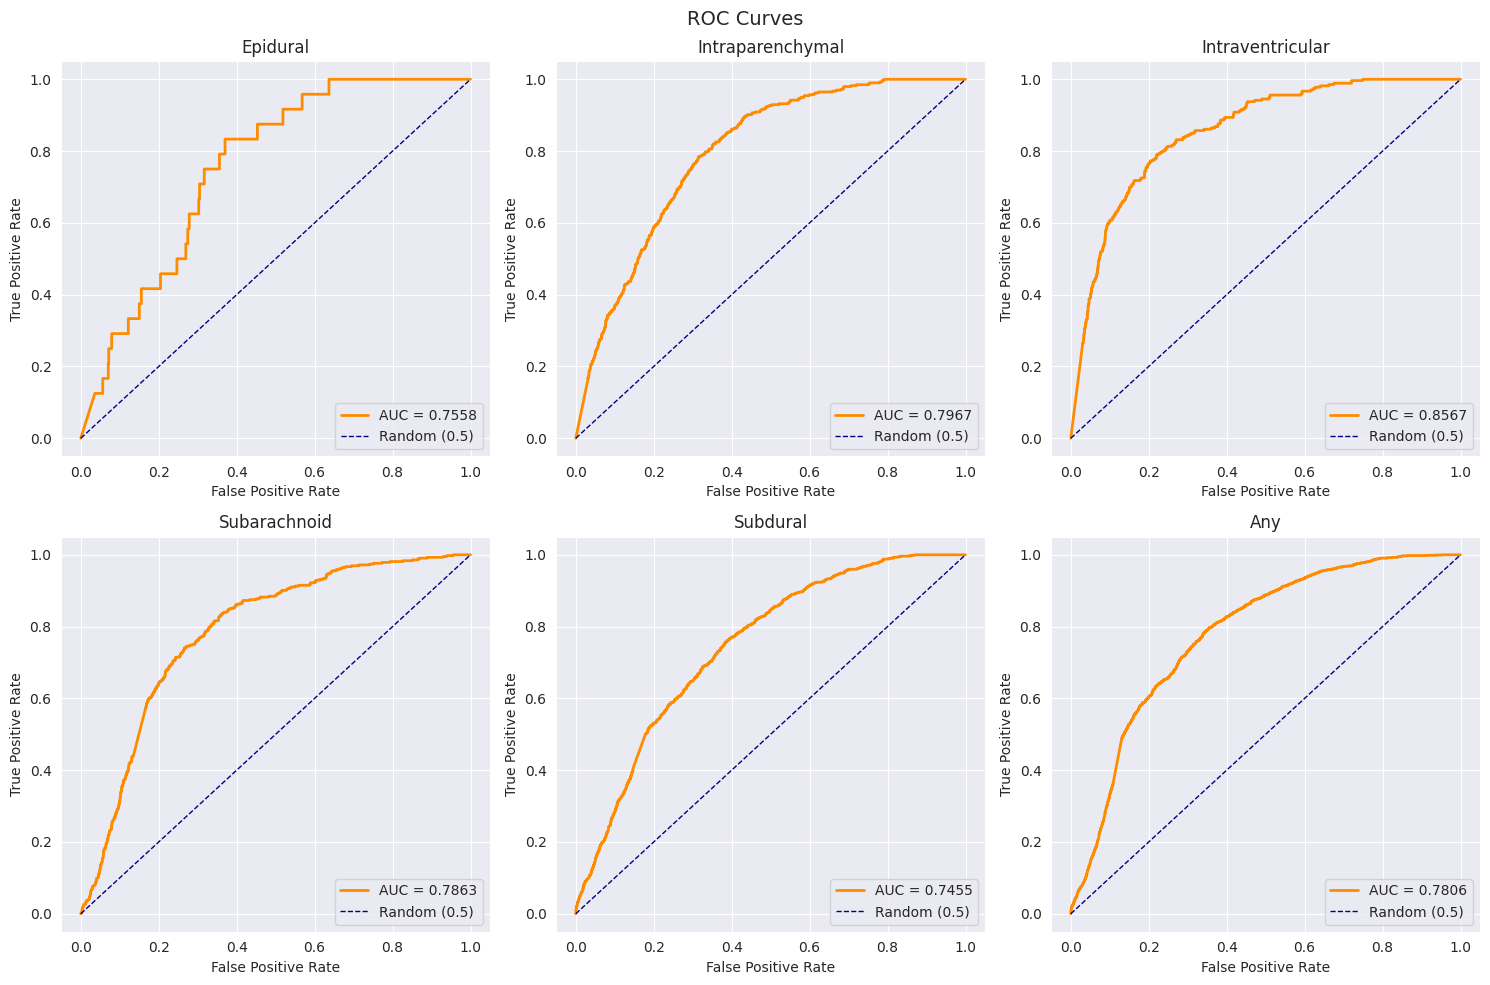

In [55]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(label_cols):
    ax = axes[i]
    try:
        fpr, tpr, _ = roc_curve(y_test[:, i], y_pred_proba[:, i])
        auc = roc_auc_score(y_test[:, i], y_pred_proba[:, i])
        ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc:.4f}')
    except ValueError:
        ax.text(0.5, 0.5, 'No positive cases', ha='center', va='center', fontsize=12)
    
    ax.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random (0.5)')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(col.replace('_', ' ').title())
    ax.legend(loc='lower right')

plt.suptitle('ROC Curves', fontsize=14)
plt.tight_layout()
plt.savefig('roc_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

# TO-DO
- use volumetric instead of just 1 slice for classification
- segmentation test can use the rsna data right? cause it is volumetric
- LSTM?